# 🏥 Clinical Appointment No-Show Prediction AI Agent

This project builds a hybrid AI system that predicts patient no-shows using a machine learning model and enhances it with LLM-based reasoning and Retrieval-Augmented Generation (RAG)


### 🔧 Pipeline Overview:

```
                → High Risk → Retrieval (FAISS) → Recommendation (LLM) → Strong Intervention
Input → ML Model → Risk Analysis (LLM) →
                 → Medium Risk → Recommendation (LLM) → SMS / Call  
                 → Low Risk → Recommendation (LLM) → Minimal Action
```

This system follows a **decision-aware hybrid AI pipeline**:

**Step 1: Prediction**
- Input patient data is processed and passed through a trained ML model (Decision Tree)
- The model outputs a **no-show probability**

**Step 2: Risk Analysis (LLM)**
- An LLM interprets the prediction using key features:
  - `waiting_days`
  - `age`
  - `SMS_received`

**Step 3: Conditional Routing (LangGraph)**
Based on predicted probability:
- 🔴 **High Risk (> 0.65)**  
  → Retrieval (FAISS) → Recommendation (LLM) → Strong Intervention  
- 🟡 **Medium Risk (0.45–0.65)**  
  → Direct Recommendation (LLM) → SMS / Call  
- 🟢 **Low Risk (< 0.45)**  
  → Direct Recommendation (LLM) → Minimal Action  

**Step 4: Recommendation Generation**
- The LLM generates **structured, actionable outputs** tailored to risk level

### 💡 Key Insight

The system intelligently **adapts its pipeline based on risk level**, ensuring:
- Efficient use of resources (RAG only when needed)
- Focused intervention for high-risk patients
- Scalable and practical deployment in healthcare systems


This design mirrors real-world clinical workflows where intervention intensity is dynamically adjusted based on patient risk.

Currently the system is stateless for simplicity and reliability. However, it can be extended with a patient history memory module to improve personalization and long-term decision-making.

## ⚙️ Setup & Dependencies
Install required libraries for LangChain, LangGraph, FAISS, and LLM integration.

In [5]:
!pip install langchain langgraph langchain-community langchain-groq faiss-cpu streamlit sentence-transformers

In [6]:
!pip install graphviz

## 🤖 LLM Setup (Groq API)
We use Groq’s LLaMA model for reasoning and recommendation generation.

In [7]:
import os
from langchain_groq import ChatGroq
from google.colab import userdata

# Load API key from Colab secrets
groq_api_key = userdata.get("GROQ_API_KEY")

llm = ChatGroq(
    groq_api_key=groq_api_key,
    model_name="llama-3.3-70b-versatile"
)

# Test LLM
response = llm.invoke("Explain what is a no-show in healthcare in 2 lines.")
print(response.content)

In healthcare, a no-show refers to a patient who fails to attend a scheduled appointment or procedure without prior notification or cancellation. No-shows can result in wasted resources, lost revenue, and delayed care for other patients, making them a significant concern for healthcare providers.


## 🧠 Load Trained ML Model
Load the pre-trained Decision Tree model used for no-show prediction.

In [8]:
import pickle

# Load trained model
with open("best_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded successfully")

Model loaded successfully


## 📊 ML Prediction Function
This function takes patient features and returns:
- Prediction (0/1)
- Probability of no-show

In [9]:
import pandas as pd

def predict_no_show(features_dict):
    """
    features_dict: dictionary with feature names
    """

    input_df = pd.DataFrame([features_dict])

    # Ensure correct column order
    input_df = input_df[model.feature_names_in_]

    prob = model.predict_proba(input_df)[0][1]
    prediction = model.predict(input_df)[0]

    return {
        "prediction": int(prediction),
        "probability": float(prob)
    }

In [10]:
sample = {
    "Gender": 1,
    "Age": 25,
    "Scholarship": 0,
    "Hipertension": 0,
    "Diabetes": 0,
    "Alcoholism": 0,
    "Handcap": 0,
    "SMS_received": 0,
    "waiting_days": 10,
    "appointment_day_of_week": 2
}

print(predict_no_show(sample))

{'prediction': 1, 'probability': 0.6888742164112941}


## 🧩 Agent State Definition
Defines the shared state passed between different nodes in the agent pipeline.

In [11]:
from typing import TypedDict, List, Dict

class AgentState(TypedDict):
    input_data: Dict
    prediction: int
    probability: float
    risk_analysis: str
    retrieved_docs: List[str]
    final_recommendation: str

## 🔍 Risk Analysis Node (LLM)
This node:
- Calls ML model
- Uses LLM to explain WHY the patient is high/low risk

In [12]:
def risk_analysis_node(state: AgentState):

    input_data = state["input_data"]

    # Get ML prediction
    result = predict_no_show(input_data)

    prediction = result["prediction"]
    probability = result["probability"]

    # LLM reasoning
    prompt = f"""
      You are a healthcare risk analysis assistant.

      Patient Data:
      {input_data}

      Predicted No-show Probability: {probability:.2f}

      Important Context:
      - The ML model identifies 'waiting_days' as the MOST important feature
      - 'age' and 'SMS_received' also influence the prediction
      - Ignore all other features unless absolutely necessary

      Focus on key factors:
      - waiting_days
      - age
      - SMS_received

      Risk Level Rule:
      - >0.65 → High
      - 0.45–0.65 → Medium
      - <0.45 → Low

      Instructions:
    - Base your reasoning on the ML model behavior
    - Do NOT make assumptions beyond given features
    - Do NOT simply restate the probability
    - Be concise (max 100 words)

      Explain:
      1. Risk level reasoning (Why this patient is high/low risk)
      2. Top contributing features (Which features contributed MOST)

      Output EXACTLY in this format:
      Risk Level Reasoning:
      Top Contributing Factors:
    """

    response = llm.invoke(prompt)

    return {
        "prediction": prediction,
        "probability": probability,
        "risk_analysis": response.content
    }

In [13]:
state = {
    "input_data": sample,
    "prediction": None,
    "probability": None,
    "risk_analysis": "",
    "retrieved_docs": [],
    "final_recommendation": ""
}

output = risk_analysis_node(state)
print(output["risk_analysis"])

Risk Level Reasoning: 
The patient is at high risk due to a long waiting period (10 days) and no SMS received, which likely contributed to the high no-show probability.

Top Contributing Factors: 
Waiting days (most important), age, and lack of SMS received.


## 📚 Knowledge Base (RAG Setup)
We create a small healthcare knowledge base and store it using FAISS for retrieval.

In [14]:
documents = [
    "Patients with long waiting times are more likely to miss appointments.",
    "Sending SMS reminders 24 hours before reduces no-show rates significantly.",
    "Elderly patients with chronic conditions are more likely to attend appointments.",
    "Follow-up phone calls are effective for high-risk patients.",
    "Overbooking strategies can be used for high no-show probability patients."
]

In [15]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding = HuggingFaceEmbeddings()
vectorstore = FAISS.from_texts(documents, embedding)

/tmp/ipykernel_7000/1103269893.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding = HuggingFaceEmbeddings()
/tmp/ipykernel_7000/1103269893.py:4: LangChainDeprecationWarning: Default values for HuggingFaceEmbeddings.model_name were deprecated in LangChain 0.2.16 and will be removed in 0.4.0. Explicitly pass a model_name to the HuggingFaceEmbeddings constructor instead.
  embedding = HuggingFaceEmbeddings()
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/toke

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
def retrieve_docs(query):
    docs = vectorstore.similarity_search(query, k=2)
    return [doc.page_content for doc in docs]

print(retrieve_docs("high no-show risk patient"))

['Overbooking strategies can be used for high no-show probability patients.', 'Patients with long waiting times are more likely to miss appointments.']


## 🔎 Retrieval Node
Fetches relevant healthcare guidelines based on risk analysis.

In [17]:
def retrieval_node(state: AgentState):

    input_data = state["input_data"]
    probability = state["probability"]

    # Determine risk label
    if probability > 0.65:
        risk = "high"
    elif probability > 0.45:
        risk = "medium"
    else:
        risk = "low"

    query = f"""
    {risk} no-show risk patient
    waiting_days: {input_data['waiting_days']}
    age: {input_data['Age']}
    sms_received: {input_data['SMS_received']}
    """

    docs = retrieve_docs(query)

    return {
        "retrieved_docs": docs
    }

In [18]:
state.update(output)  # from previous node
retrieved = retrieval_node(state)
print(retrieved["retrieved_docs"])

['Overbooking strategies can be used for high no-show probability patients.', 'Patients with long waiting times are more likely to miss appointments.']


## 🎯 Recommendation Node
Combines:
- Risk analysis
- Retrieved knowledge
- Probability

To generate final actionable recommendations.

In [ ]:
def recommendation_node(state: AgentState):

    risk = state["risk_analysis"]
    docs = state["retrieved_docs"]
    probability = state["probability"]

    # Convert docs to clean format
    docs_text = "\n".join(f"- {doc}" for doc in docs)

    # Rule-based decision
    if probability > 0.65:
        action_hint = "Call + SMS + Consider Overbooking"
        risk_level = "High"
    elif probability > 0.45:
        action_hint = "SMS Reminder"
        risk_level = "Medium"
    else:
        action_hint = "Standard Reminder"
        risk_level = "Low"

    prompt = f"""
    You are an AI healthcare care-coordination assistant.

    Patient Risk Analysis:
    {risk}

    Retrieved Guidelines:
    {docs_text}

    No-show Probability: {probability:.2f}

    Pre-determined Risk Level: {risk_level}
    Mandatory baseline action: {action_hint}

    Based on this:
    1. Explain key factors briefly
    2. Suggest clear actions:
       - SMS / Call / Reschedule / Overbooking

    Instructions:
    - You MUST follow the baseline action
    - You MUST strictly follow the baseline action. Do not override it.
    - Keep response concise and structured
    - Do NOT introduce new assumptions beyond given data
    - Do NOT contradict the ML prediction

    Output format:
    Risk Level:
    Key Factors:
    Recommended Action:
    """

    response = llm.invoke(prompt)

    return {
        "final_recommendation": response.content
    }

In [20]:
state = {
    "input_data": sample,
    "prediction": None,
    "probability": None,
    "risk_analysis": "",
    "retrieved_docs": [],
    "final_recommendation": ""
}

# Step 1: Risk
state.update(risk_analysis_node(state))

# Step 2: Retrieval
state.update(retrieval_node(state))

# Step 3: Recommendation
state.update(recommendation_node(state))

print(state["final_recommendation"])

Risk Level: High
Key Factors: Long waiting period (10 days), age (25), and lack of SMS reminder
Recommended Action: Call + SMS + Consider Overbooking


## 🔗 LangGraph Agent Pipeline
We convert the pipeline into a structured graph:
Risk → Retrieval → Recommendation

In [21]:
def route_risk(state: AgentState):
    prob = state["probability"]

    if prob > 0.65:
        return "high_risk"
    elif prob > 0.45:
        return "medium_risk"
    else:
        return "low_risk"

In [22]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(AgentState)

# Add Nodes

builder.add_node("Risk Analysis", risk_analysis_node)
builder.add_node("Retrieval (FAISS)", retrieval_node)
builder.add_node("Recommendation", recommendation_node)

In [33]:
# Build Graph
builder.add_edge(START, "Risk Analysis")

builder.add_conditional_edges(
    "Risk Analysis",
    route_risk,
    {
        "high_risk": "Retrieval (FAISS)", # full pipeline
        "medium_risk": "Recommendation",  # skip retrieval
        "low_risk": "Recommendation"      # simple path
    }
)

# normal flow after retrieval
builder.add_edge("Retrieval (FAISS)", "Recommendation")
builder.add_edge("Recommendation", END)

# end
graph = builder.compile()

ValueError: Branch with name `route_risk` already exists for node `Risk Analysis`

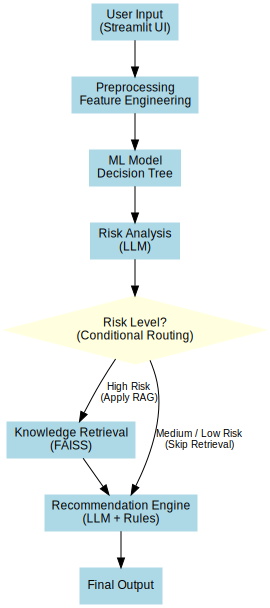

In [34]:
# Visualize Graph
from graphviz import Digraph

dot = Digraph(format='png')
dot.attr(rankdir='TB', size='8,10')

# Font styling
dot.attr('node', fontname="Helvetica", fontsize="12")
dot.attr('edge', fontname="Helvetica", fontsize="10")

# Default node style
dot.attr('node', shape='box', style='filled', color='lightblue')

# Nodes
dot.node('A', 'User Input\n(Streamlit UI)')
dot.node('B', 'Preprocessing\nFeature Engineering')
dot.node('C', 'ML Model\nDecision Tree')
dot.node('D', 'Risk Analysis\n(LLM)')

# Decision node (different style)
dot.node('E', 'Risk Level?\n(Conditional Routing)',
         shape='diamond', style='filled', color='lightyellow')

dot.node('F', 'Knowledge Retrieval\n(FAISS)')
dot.node('G', 'Recommendation Engine\n(LLM + Rules)')
dot.node('H', 'Final Output')

# Main Flow
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')

# Conditional Branches (UPGRADED)
dot.edge('E', 'F', label='High Risk\n(Apply RAG)')
dot.edge('E', 'G', label='Medium / Low Risk\n(Skip Retrieval)')

# Continue flow
dot.edge('F', 'G')
dot.edge('G', 'H')

dot

## 🚀 Final Agent Execution
Run the complete pipeline on sample input.

In [25]:
state = {
    "input_data": sample,
    "prediction": None,
    "probability": None,
    "risk_analysis": "",
    "retrieved_docs": [],
    "final_recommendation": ""
}

result = graph.invoke(state)
print(result["final_recommendation"])

Risk Level: High
Key Factors: Long waiting period (10 days), lack of SMS reminder, and age
Recommended Action: Call the patient, send an SMS reminder, and consider overbooking to mitigate the high no-show probability.


### 💡 Key Design Decisions

- We prioritize Recall in the ML model to minimize missed no-show cases
- We use rule-based thresholds for deterministic decision-making
- We separate decision logic from LLM reasoning to ensure reliability and consistency
- We constrain the LLM to enhance, not override decisions
- We apply conditional routing to optimize system efficiency

### Final Output Explanation

The system operates as a hybrid AI agent with decision-aware execution:

1. Predicts no-show probability using a trained ML model (Decision Tree)
2. Uses an LLM for controlled, feature-grounded risk analysis to ensure interpretability and reduce hallucination
3. Applies conditional routing using LangGraph:
   - High-risk patients trigger knowledge retrieval (FAISS)
   - Medium/Low-risk patients skip retrieval for efficiency
4. Retrieves relevant healthcare guidelines only when necessary (RAG)
5. Generates structured, actionable recommendations using an LLM

This demonstrates a decision-aware hybrid AI system combining predictive modeling, controlled LLM reasoning, and adaptive retrieval for efficient, interpretable, and scalable healthcare decision-making.